# Proyek Akhir: Menyelesaikan Permasalahan Human Resources

- Nama: Daffa Rizqianaufal Maulidsyah
- Email: daffarizqii218@gmail.com
- Id Dicoding: daffa1212

## Persiapan

### Menyiapkan library yang dibutuhkan

Tahap ini memuat library untuk pengolahan data, visualisasi, pemodelan, dan penyimpanan model.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
BASE_DIR = Path('.')


### Menyiapkan data yang akan diguankan

Dataset yang digunakan berada pada `data/employee_data.csv`. Analisis attrition hanya menggunakan baris yang memiliki label valid pada kolom `Attrition`.

## Data Understanding

Pada bagian ini dilakukan pengecekan ukuran data, tipe data, missing values, serta identifikasi kolom yang tidak informatif untuk analisis/modeling.

In [2]:
df = pd.read_csv(BASE_DIR / 'data' / 'employee_data.csv')
print('Shape dataset:', df.shape)
print('\nTipe data:')
display(df.dtypes.to_frame('dtype').T)

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('\nMissing values per kolom:')
display(missing.to_frame('missing_rows'))

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print('\nKolom konstan / tidak informatif:', constant_cols)
print('\nContoh 5 baris data:')
display(df.head())


Shape dataset: (1470, 35)

Tipe data:


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
dtype,int64,int64,float64,object,int64,object,int64,int64,object,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64



Missing values per kolom:


,missing_rows
Attrition,412



Kolom konstan / tidak informatif: ['EmployeeCount', 'Over18', 'StandardHours']

Contoh 5 baris data:


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Preparation / Preprocessing

Langkah yang dilakukan:
- Menghapus baris tanpa label attrition untuk analisis klasifikasi.
- Mengubah `Attrition` menjadi integer.
- Membuat fitur segmentasi (`AgeBand`, `IncomeBand`, `TenureBand`) untuk analisis dashboard.
- Menghapus kolom identitas dan kolom konstan saat modeling.
- Melakukan imputasi, scaling, dan one-hot encoding di dalam pipeline.

Total data: 1470
Data berlabel: 1058
Missing label attrition: 412
Attrition rate pada data berlabel: 16.92%


,attrition_rate,jumlah_karyawan,jumlah_attrition
OverTime,,,
Yes,0.319218,307,98
No,0.107856,751,81


,attrition_rate,jumlah_karyawan,jumlah_attrition
BusinessTravel,,,
Travel_Frequently,0.248780,205,51
Travel_Rarely,0.156836,746,117
Non-Travel,0.102804,107,11


,attrition_rate,jumlah_karyawan,jumlah_attrition
JobRole,,,
Sales Representative,0.431034,58,25
Laboratory Technician,0.260638,188,49
Human Resources,0.200000,30,6
Research Scientist,0.177570,214,38
Sales Executive,0.168103,232,39
Healthcare Representative,0.090909,88,8
Manufacturing Director,0.065421,107,7
Manager,0.063291,79,5
Research Director,0.032258,62,2


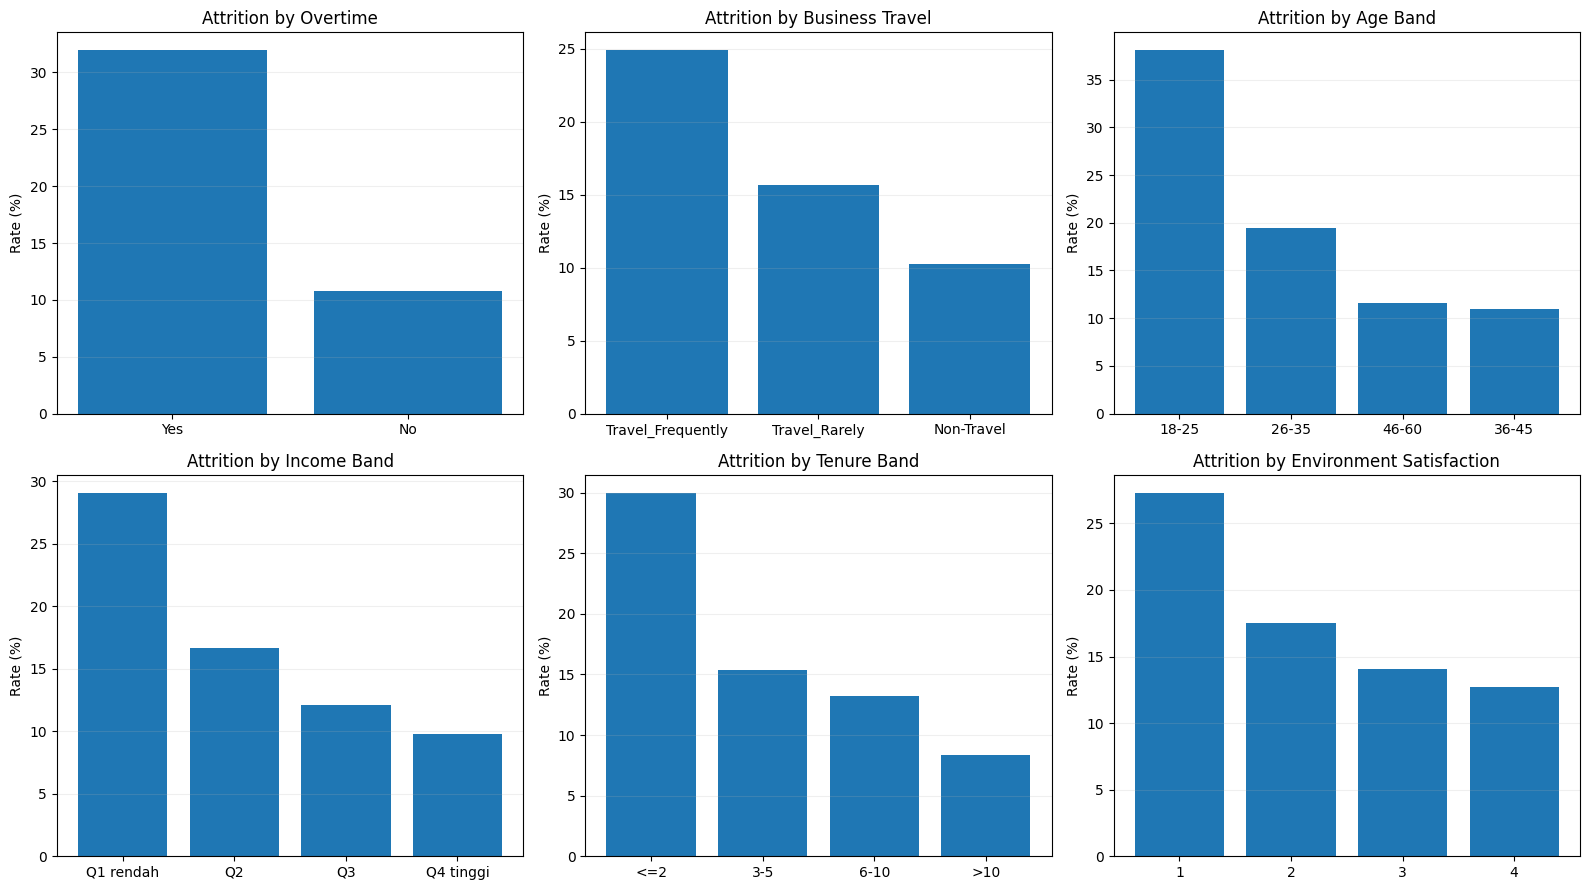

In [3]:
labeled = df.dropna(subset=['Attrition']).copy()
labeled['Attrition'] = labeled['Attrition'].astype(int)
labeled['AgeBand'] = pd.cut(labeled['Age'], bins=[17, 25, 35, 45, 60], labels=['18-25', '26-35', '36-45', '46-60'])
labeled['IncomeBand'] = pd.qcut(labeled['MonthlyIncome'], q=4, labels=['Q1 rendah', 'Q2', 'Q3', 'Q4 tinggi'])
labeled['TenureBand'] = pd.cut(labeled['YearsAtCompany'], bins=[-1, 2, 5, 10, 40], labels=['<=2', '3-5', '6-10', '>10'])

print('Total data:', len(df))
print('Data berlabel:', len(labeled))
print('Missing label attrition:', df['Attrition'].isna().sum())
print(f'Attrition rate pada data berlabel: {labeled["Attrition"].mean()*100:.2f}%')

def attrition_table(col):
    return (
        labeled.groupby(col, observed=False)['Attrition']
        .agg(attrition_rate='mean', jumlah_karyawan='count', jumlah_attrition='sum')
        .sort_values('attrition_rate', ascending=False)
    )

display(attrition_table('OverTime'))
display(attrition_table('BusinessTravel'))
display(attrition_table('JobRole').head(10))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col, title in [
    (axes[0,0], 'OverTime', 'Attrition by Overtime'),
    (axes[0,1], 'BusinessTravel', 'Attrition by Business Travel'),
    (axes[0,2], 'AgeBand', 'Attrition by Age Band'),
    (axes[1,0], 'IncomeBand', 'Attrition by Income Band'),
    (axes[1,1], 'TenureBand', 'Attrition by Tenure Band'),
    (axes[1,2], 'EnvironmentSatisfaction', 'Attrition by Environment Satisfaction'),
]:
    tab = attrition_table(col)
    vals = tab['attrition_rate'].mul(100)
    ax.bar(range(len(vals)), vals.values)
    ax.set_title(title)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([str(i) for i in vals.index], rotation=20 if len(vals)>4 else 0)
    ax.set_ylabel('Rate (%)')
    ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


## Modeling

Model yang digunakan adalah **Extra Trees Classifier**. Pemodelan dilakukan pada data berlabel dengan menghapus kolom `EmployeeId` dan kolom konstan, lalu membagi data train-test secara stratified agar proporsi kelas tetap terjaga.

In [4]:
model_df = df.dropna(subset=['Attrition']).copy()
model_df['Attrition'] = model_df['Attrition'].astype(int)
constant_cols = [c for c in model_df.columns if c != 'Attrition' and model_df[c].nunique(dropna=False) <= 1]

X = model_df.drop(columns=['Attrition', 'EmployeeId'] + constant_cols)
y = model_df['Attrition']

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=2
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipeline.fit(X_train, y_train)
proba = pipeline.predict_proba(X_test)[:, 1]

best_threshold, best_f1 = 0.5, -1
for t in np.arange(0.2, 0.81, 0.01):
    pred = (proba >= t).astype(int)
    score = f1_score(y_test, pred)
    if score > best_f1:
        best_threshold = float(t)
        best_f1 = float(score)

print('Threshold optimal:', round(best_threshold, 2))
print('Jumlah fitur training:', len(X.columns))
print('Fitur kategorikal:', categorical_cols)


Threshold optimal: 0.44
Jumlah fitur training: 30
Fitur kategorikal: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## Evaluation

Evaluasi dilakukan menggunakan metrik klasifikasi utama dan permutation importance. Pada tahap ini juga disimpan model serta file metrik ke folder `model/` agar dapat dipakai kembali oleh prototype prediksi.

,accuracy,precision,recall,f1,roc_auc,threshold,labeled_rows,total_rows,missing_attrition
0,0.854,0.576,0.528,0.551,0.804,0.44,1058,1470,412


,importance
OverTime,0.1108
JobRole,0.0567
EnvironmentSatisfaction,0.0296
MaritalStatus,0.0143
JobSatisfaction,0.0141
EducationField,0.0127
YearsAtCompany,0.0074
JobLevel,0.0071
StockOptionLevel,0.0068
Age,0.0055


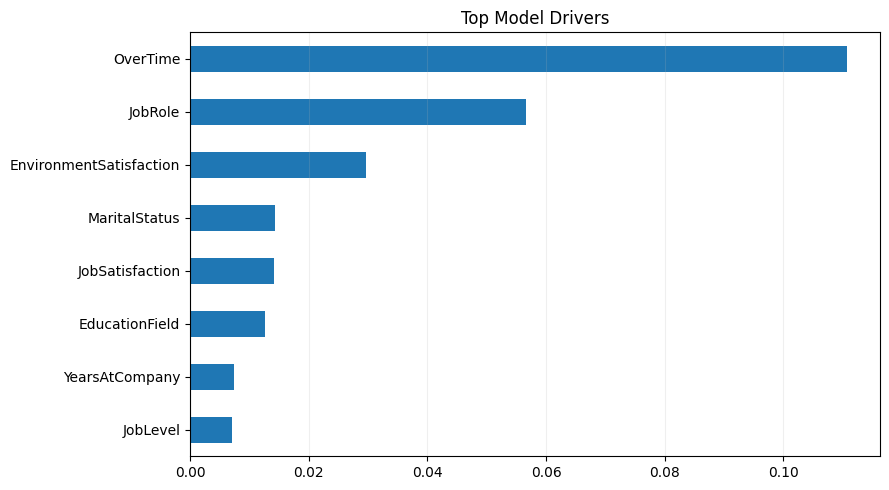

Segmen prioritas intervensi:


,JobRole,OverTime,IncomeBand,n,attrition_rate,mean_risk,median_income
68,Sales Representative,Yes,Q1 rendah,14,0.786,0.716,2304.0
20,Laboratory Technician,Yes,Q1 rendah,22,0.636,0.686,2392.0
21,Laboratory Technician,Yes,Q2,17,0.529,0.551,3691.0
52,Research Scientist,Yes,Q1 rendah,40,0.500,0.638,2380.0
62,Sales Executive,Yes,Q3,32,0.344,0.438,6146.0
63,Sales Executive,Yes,Q4 tinggi,18,0.333,0.414,10351.0
64,Sales Representative,No,Q1 rendah,30,0.267,0.355,2346.0
16,Laboratory Technician,No,Q1 rendah,71,0.197,0.229,2370.0
61,Sales Executive,Yes,Q2,16,0.188,0.284,4512.0
31,Manager,Yes,Q4 tinggi,23,0.174,0.263,16959.0


Notebook selesai dijalankan tanpa error.


In [5]:
pred = (proba >= best_threshold).astype(int)
metrics = {
    'accuracy': accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred),
    'recall': recall_score(y_test, pred),
    'f1': f1_score(y_test, pred),
    'roc_auc': roc_auc_score(y_test, proba),
    'threshold': round(best_threshold, 2),
    'labeled_rows': len(model_df),
    'total_rows': len(df),
    'missing_attrition': int(df['Attrition'].isna().sum()),
}
display(pd.DataFrame([metrics]).round(3))

perm = permutation_importance(pipeline, X_test, y_test, n_repeats=5, random_state=42, scoring='roc_auc')
importance = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
display(importance.head(10).round(4).to_frame('importance'))

importance.head(8).sort_values().plot(kind='barh', figsize=(9, 5), title='Top Model Drivers')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

joblib.dump({'pipeline': pipeline, 'threshold': best_threshold, 'features': list(X.columns)}, BASE_DIR / 'model' / 'attrition_model.joblib')
with open(BASE_DIR / 'model' / 'model_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

labeled['risk_score'] = pipeline.predict_proba(X)[:, 1]
segments = labeled.groupby(['JobRole', 'OverTime', 'IncomeBand'], observed=False).agg(
    n=('Attrition', 'size'),
    attrition_rate=('Attrition', 'mean'),
    mean_risk=('risk_score', 'mean'),
    median_income=('MonthlyIncome', 'median')
).reset_index()
segments = segments[segments['n'] >= 12].sort_values(['attrition_rate', 'mean_risk'], ascending=False)
print('Segmen prioritas intervensi:')
display(segments.head(10).round({'attrition_rate': 3, 'mean_risk': 3, 'median_income': 0}))

print('Notebook selesai dijalankan tanpa error.')
